IRIS flower data set is extremely balanced dataset, it has 3 types flower 50 each total 150,consisting of sepal length and width ,petal length and width.
Setosa is the most isolated , rest versicolor and virginica over laps but boosted decision tree or even random decision tree forest can set them apart almost accurately coz through below chart we can see petal length and petal width are deciding factor among these 2 species.

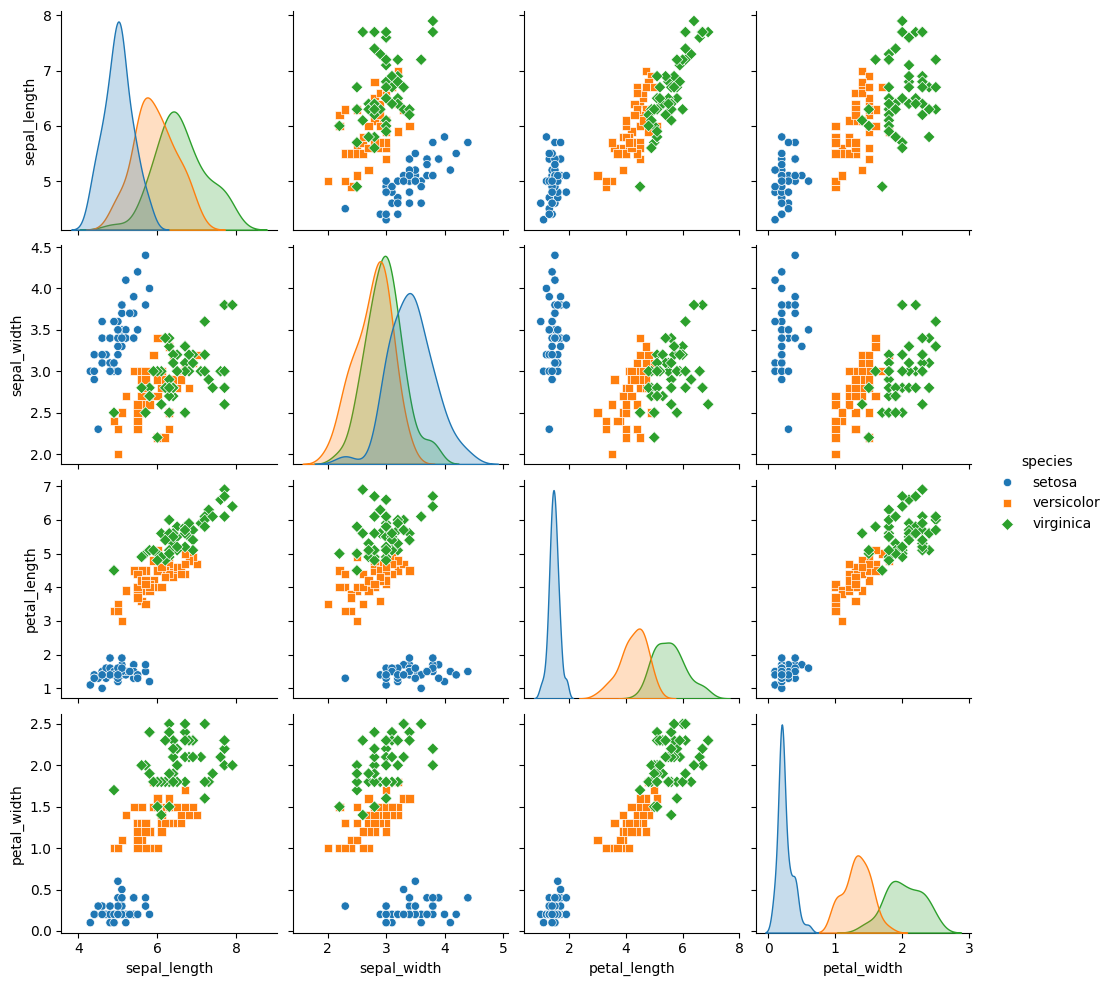

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (seaborn has it built-in)
iris_df = sns.load_dataset("iris")

# Plot all 2-feature combinations, colored by species
sns.pairplot(iris_df, hue="species", markers=["o", "s", "D"])
plt.show()

In [6]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the Data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 2. Split the Data (Stratification remains critical)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Configure and Train the Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,  # 100 independent trees
    random_state=42,
    n_jobs=-1          # Uses all CPU cores for parallel training
)

rf_model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Model Accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [7]:
import xgboost as xgb

# 3. Configure and Train the XGBoost Model
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob', # Multiclass classification
    num_class=3,                # 3 Iris species
    max_depth=4,                # Constrained depth to prevent overfitting
    learning_rate=0.1,          # Step size shrinkage
    n_estimators=50,            # Fewer trees needed for a simple dataset
    eval_metric='mlogloss',     # Multiclass logloss
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Model Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



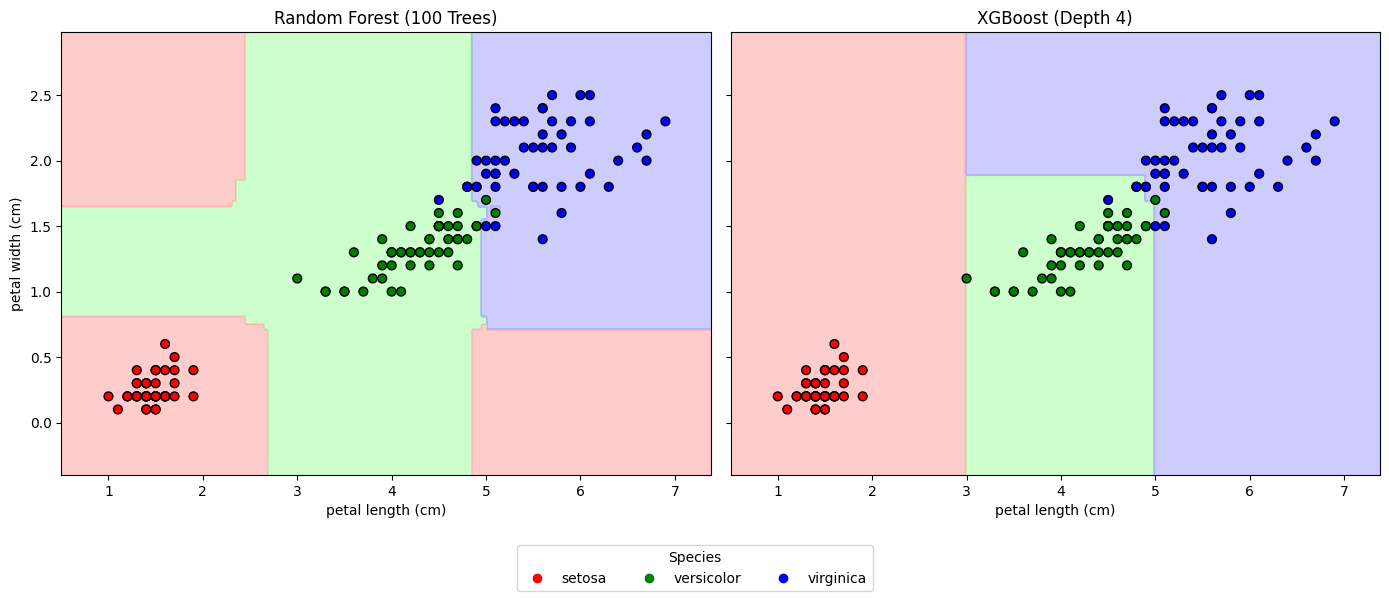

In [8]:
import numpy as np
from matplotlib.colors import ListedColormap

# Setup the 2D plane using the most defining features: Petal Length (idx 2) and Petal Width (idx 3)
feature_x_idx = 2
feature_y_idx = 3

# Create a mesh grid (the background pixels we want the models to classify)
x_min, x_max = X.iloc[:, feature_x_idx].min() - 0.5, X.iloc[:, feature_x_idx].max() + 0.5
y_min, y_max = X.iloc[:, feature_y_idx].min() - 0.5, X.iloc[:, feature_y_idx].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Calculate the mean of the other two features to pad the 4D input
mean_sepal_len = X.iloc[:, 0].mean()
mean_sepal_wid = X.iloc[:, 1].mean()

# Construct the synthetic 4D dataset for the background grid
grid_points = np.c_[
    np.full(xx.ravel().shape, mean_sepal_len), # Constant Sepal Length
    np.full(xx.ravel().shape, mean_sepal_wid), # Constant Sepal Width
    xx.ravel(),                                # Varying Petal Length
    yy.ravel()                                 # Varying Petal Width
]

# Convert to DataFrame to maintain feature names (prevents model warnings)
grid_df = pd.DataFrame(grid_points, columns=iris.feature_names)

# Predict the background grid using the PRE-TRAINED models
Z_rf = rf_model.predict(grid_df).reshape(xx.shape)
Z_xgb = xgb_model.predict(grid_df).reshape(xx.shape)

# Setup the plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#008000', '#0000FF'])

# Plot 1: Random Forest
axes[0].contourf(xx, yy, Z_rf, cmap=cmap_light, alpha=0.6)
scatter1 = axes[0].scatter(X.iloc[:, feature_x_idx], X.iloc[:, feature_y_idx], c=y,
                           cmap=cmap_bold, edgecolor='k', s=40)
axes[0].set_title('Random Forest (100 Trees)')
axes[0].set_xlabel(iris.feature_names[feature_x_idx])
axes[0].set_ylabel(iris.feature_names[feature_y_idx])

# Plot 2: XGBoost
axes[1].contourf(xx, yy, Z_xgb, cmap=cmap_light, alpha=0.6)
scatter2 = axes[1].scatter(X.iloc[:, feature_x_idx], X.iloc[:, feature_y_idx], c=y,
                           cmap=cmap_bold, edgecolor='k', s=40)
axes[1].set_title(f'XGBoost (Depth {xgb_model.max_depth})')
axes[1].set_xlabel(iris.feature_names[feature_x_idx])

# Add a legend
handles, labels = scatter1.legend_elements()
fig.legend(handles, iris.target_names, loc='lower center', ncol=3, title="Species")

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()